In [1]:
using Turing
using Jens, CUDA
using Jens:LensBase as LB
using Jens:LensUtils as LU
using Jens:LensFITS as LF
using Jens:LensGenerator as LG
using Jens:LensPlots as Jplots
using Jens:LensCosmo as LC
using Jens:LensPSF as LP

using Jens.LensModel.ComLens: CombinedLens
using Jens.LensModel: NFWE, Shear, SIS
using Jens.LightModel: CompositeImage, ExtendedSource, PointImage, PointImages
using Jens.LightModel.SersicLight: SersicSpheric
using Jens.LensSystem: ForwardModel, render
using Jens.LensSolver: solve_images
using Jens.LensPSO: lens_pso_mh, chain, chain_stats
using Jens.LensUtils: randn_like

[ Info: Precompiling Jens [51b7c8bc-8c55-4cde-95cb-80ce6c4547ac](cache misses: include_dependency fsize change (1))
[ Info: Precompiling Jens [51b7c8bc-8c55-4cde-95cb-80ce6c4547ac] (cache misses: include_dependency fsize change (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing Jens [51b7c8bc-8c55-4cde-95cb-80ce6c4547ac].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
[ Info: Precompiling JensCUDA [b50c7a95-6ca5-5c7e-ae97-b6132035395f](cache misses: wrong dep version loaded (1))
[ Info: Precompiling JensCUDA [b50c7a95-6ca5-5c7e-ae97-b6132035395f] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to print a f

### This tutorial uses multiple Metropolis--Hastings (MH) algorithms to fit the parameters. Consequently, the final results may converge to a local minimum.

In [2]:
# Cosmology + grid + PSF 
cosmo = LC.Cosmology.FlatLCDM(0.7, 0.3, 0.0, 0.0)
z_lens, z_src = 0.3, 1.5
sigma_data = 0.1

grid_cpu = LG.GenGrid(pix_n=64, pix_size=0.06)              # CPU
grid_gpu = gpu_grid(pix_n=64, pix_size=Float32(0.06))  # GPU

psf = LP.GaussianPSF(; fwhm=0.1)

Jens.LensPSF.GaussianPSF{Float64}(0.1)

In [3]:
# Lens model
lens = CombinedLens(
    NFWE   => (Rs=1., alpha_Rs=1.0, e1=0.2, e2=0.1, xcentre=0.0, ycentre=0.0),
    Shear => (gamma1=0.05, gamma2=-0.03, xcentre=0.0, ycentre=0.0))

CombinedLens{Tuple{Module, Module}, Tuple{@NamedTuple{Rs::Float64, alpha_Rs::Float64, e1::Float64, e2::Float64, xcentre::Float64, ycentre::Float64}, @NamedTuple{gamma1::Float64, gamma2::Float64, xcentre::Float64, ycentre::Float64}}}((Jens.LensModel.NFWE, Jens.LensModel.Shear), ((Rs = 1.0, alpha_Rs = 1.0, e1 = 0.2, e2 = 0.1, xcentre = 0.0, ycentre = 0.0), (gamma1 = 0.05, gamma2 = -0.03, xcentre = 0.0, ycentre = 0.0)))

In [4]:
agn_images = solve_images(lens, 0.01, -0.03; z_source=z_src)
agn_positions = [(x, y) for (x, y, _) in agn_images]

5-element Vector{Tuple{Float64, Float64}}:
 (-0.0010669633304918403, 0.0027313685882620173)
 (0.9056130983382834, 0.37524582198598666)
 (-0.3622203847965429, 0.8923861864490169)
 (-0.963118400790499, -0.26332905028641845)
 (0.38460009340683593, -0.9515857206850927)

In [5]:
# Light model
# host
host = ExtendedSource(SersicSpheric;
    amp=2.0, Rsersic=1.0, n=2.0, xcentre=0.01, ycentre=-0.01)

# point source
agn =  PointImages((2.0, agn_positions); intrinsic=true)

# combine
src = CompositeImage(host, agn)

CompositeImage{Tuple{ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}, PointImages{Float64}}}((ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}(Jens.LightModel.SersicLight.SersicSpheric, (amp = 2.0, Rsersic = 1.0, n = 2.0, xcentre = 0.01, ycentre = -0.01)), PointImages{Float64}([(2.0, [(-0.0010669633304918403, 0.0027313685882620173), (0.9056130983382834, 0.37524582198598666), (-0.3622203847965429, 0.8923861864490169), (-0.963118400790499, -0.26332905028641845), (0.38460009340683593, -0.9515857206850927)])], true)))

In [6]:
sys = ForwardModel(
    lens_plane   = LG.LensedPlane(lens; z_lens, cosmology=cosmo),
    source_plane = LG.LightPlane(src; z=z_src),
    grid = grid_gpu, psf = psf,
)

@time img = render(sys);

  8.018803 seconds (27.14 M allocations: 1.335 GiB, 5.98% gc time, 89.50% compilation time: <1% of which was recompilation)


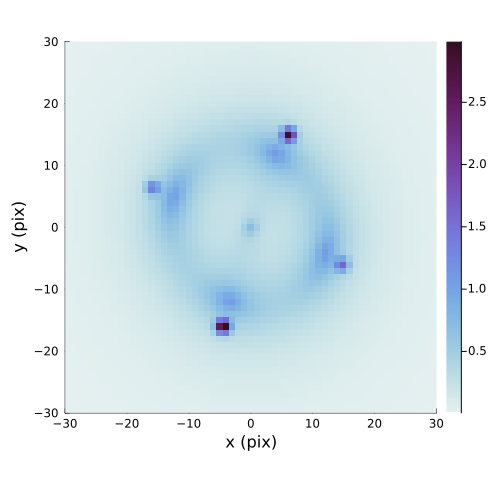

In [7]:
canvas = Jplots.LensCanvas(;  xlims=(-30,30), ylims=(-30,30),
        size=(500,500))
Jplots.PlotPlane!(canvas, Array(img) )
display(canvas)

In [8]:
# SIM real img
sigma = max(median(abs.(img)) * 0.1, 1e-3)           # noise

data_noisy = img .+ sigma .* randn_like(img);

In [30]:
# render model
function build_renderer(grid, psf, cosmo, z_lens, z_src, agn_pos)
    function render_for(p)
        Rs, alpha_Rs, e1, e2, amp, rsr, n, flux = p
        lens = LG.LensedPlane(CombinedLens(NFWE => (
            Rs=Rs, alpha_Rs=alpha_Rs, e1=e1, e2=e2,
            xcentre=0.0, ycentre=0.0),
            Shear => (gamma1=0.05, gamma2=-0.03, xcentre=0.0, ycentre=0.0)
            ); z_lens=z_lens, cosmology=cosmo)
        host = ExtendedSource(SersicSpheric; amp=amp, 
                    Rsersic=rsr, n=n, xcentre=0.01, ycentre=-0.01)
        agn  = PointImages((flux, agn_pos); intrinsic=true)
        fwd  = ForwardModel(lens_plane=lens,
            source_plane=LG.LightPlane(CompositeImage(host, agn); z=z_src),
            grid=grid, psf=psf)
        return render(fwd)
    end
    return render_for
end

# likelihood
function build_logp(data, grid, psf, cosmo, z_lens, z_src, agn_pos)
    function logp_fn(p)

        # set the Parameters
        Rs, alpha_Rs, e1, e2, amp, rsr, n, flux = p

        # set model
        render_model = build_renderer(grid, psf, cosmo, z_lens, z_src, agn_pos)
        N = length(data)

        (Rs > 0 && alpha_Rs > 0 && rsr > 0 && n > 0.2 && amp > 0 && flux > 0 && sigma_data > 0) || return -Inf
        abs(e1) < 1 && abs(e2) < 1 && e1^2 + e2^2 < 1 || return -Inf

        # render image
        img = try render_model(p) catch; return -Inf end

        # logp
        logp = - 0.5 * sum(((data .- img) ./ sigma_data).^2)

        return logp
    end
    return logp_fn
end

build_logp (generic function with 1 method)

In [31]:
logp = build_logp(data_noisy, grid_gpu, psf, cosmo, z_lens, z_src, agn_positions)

(::var"#logp_fn#build_logp##1"{CuArray{Float64, 2, CUDACore.DeviceMemory}, JensCUDA.GridGPU{CuArray{Float32, 2, CUDACore.DeviceMemory}}, Jens.LensPSF.GaussianPSF{Float64}, Cosmology.FlatLCDM{Float64}, Float64, Float64, Vector{Tuple{Float64, Float64}}}) (generic function with 1 method)

In [42]:
using Jens.LensMH: lens_mh_multistart, chain
# prior bounds 
#          Rs     α_Rs    e1      e2     amp    Rsrs    n     flux  
lower_n = [0.1,   0.5,    -0.4,   -0.4,  0.2,   0.08,  0.5,   1.0]
upper_n = [5.0,   2.5,     0.4,    0.4,  3.0,   2.0,   5.0,   5.0]

@time res = lens_pso_mh(logp, lower_n, upper_n; 
            n_particles = 64, n_iter = 400, n_mh = 6000, 
                        seed = 42)

 14.221267 seconds (87.48 M allocations: 14.148 GiB, 34.57% gc time, 2 lock conflicts)


Jens.LensPSO.PSOResult([0.8807685841137354, 0.9782260637648936, 0.2148924711275481, 0.11255663743810751, 1.5307444091312397, 0.7900938745386646, 1.656977412909048, 2.374641752502444], -26.609634582736266, [-3061.0985596129503, -2157.7399558881625, -2157.7399558881625, -2157.7399558881625, -2157.7399558881625, -2157.7399558881625, -2157.7399558881625, -2157.7399558881625, -2157.7399558881625, -2157.7399558881625  …  -28.10392346657298, -28.10392346657298, -28.072470103765102, -28.072470103765102, -28.072470103765102, -28.033766420400095, -27.99717706714292, -27.703085056518304, -27.179202406653545, -26.609634582736266], [0.8807148158762248 9.867264010726224 … 0.8801534043140776 13.106553400202532; 0.9802526414365997 1.0014485221448988 … 0.9782704081685477 0.9748236390741555; … ; 1.647065417463564 1.5493704448515913 … 1.629966141812281 23.510929526572554; 2.384016528677576 2.317959032892224 … 2.3527667394989344 2.1028239705246077], Jens.LensMH.MHResult([0.8807685841137354 0.8807685841137

In [43]:
# summary
summary = chain(res; burn=100)          # (n_params, n_samples) 
means, stds = chain_stats(res; burn=100)

best_p = vec(mean(summary; dims=2)) 
render_for = build_renderer(grid_gpu, psf, cosmo, z_lens, z_src, agn_positions)
img_best  = render_for(best_p);

In [44]:
# Results
names = ["Rs", "alpha_Rs", "e1", "e2", "amp_host", "Rsersic", "n", "flux_agn"]
tvals = [1.0, 1.0, 0.2, 0.1, 2.0, 1., 2.0, 2.0]

println("\n" * "="^70)
println("  Parameter       Truth        Mean ± Std           Δ/σ")
println("─"^70)
for i in 1:7
    m, s = mean(summary[i,:]), std(summary[i,:])
    ds = (m - tvals[i]) / (s + 1e-10)
    flag = abs(ds) < 3.0 ? " ✓" : " ⚠"
    tv = round(tvals[i], digits=3)
    println("  ", rpad(names[i], 12), "  ", rpad(string(tv), 8),
            "  ", lpad(round(m, digits=4), 8), " ± ", rpad(round(s, digits=4), 8),
            "  ", lpad(round(ds, digits=1), 4), "σ", flag)
end
println("\nDone.")


  Parameter       Truth        Mean ± Std           Δ/σ
──────────────────────────────────────────────────────────────────────
  Rs            1.0         0.9258 ± 0.0303    -2.4σ ✓
  alpha_Rs      1.0         0.9881 ± 0.0055    -2.2σ ✓
  e1            0.2         0.2098 ± 0.0034     2.9σ ✓
  e2            0.1         0.1081 ± 0.0035     2.3σ ✓
  amp_host      2.0         1.6363 ± 0.0621    -5.9σ ⚠
  Rsersic       1.0         0.8131 ± 0.0352    -5.3σ ⚠
  n             2.0         1.7303 ± 0.0516    -5.2σ ⚠

Done.


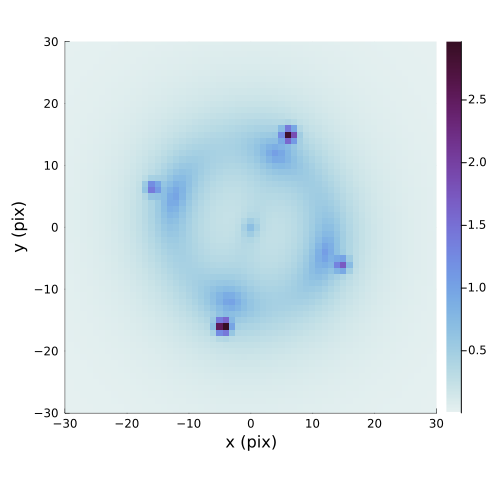

In [45]:
# fitness image
canvas_f = Jplots.LensCanvas(;  xlims=(-30,30), ylims=(-30,30),
        size=(500,500))
Jplots.PlotPlane!(canvas_f, Array(img_best) )
display(canvas_f)

In [15]:
using StatsPlots,PairPlots, MCMCChains, CairoMakie

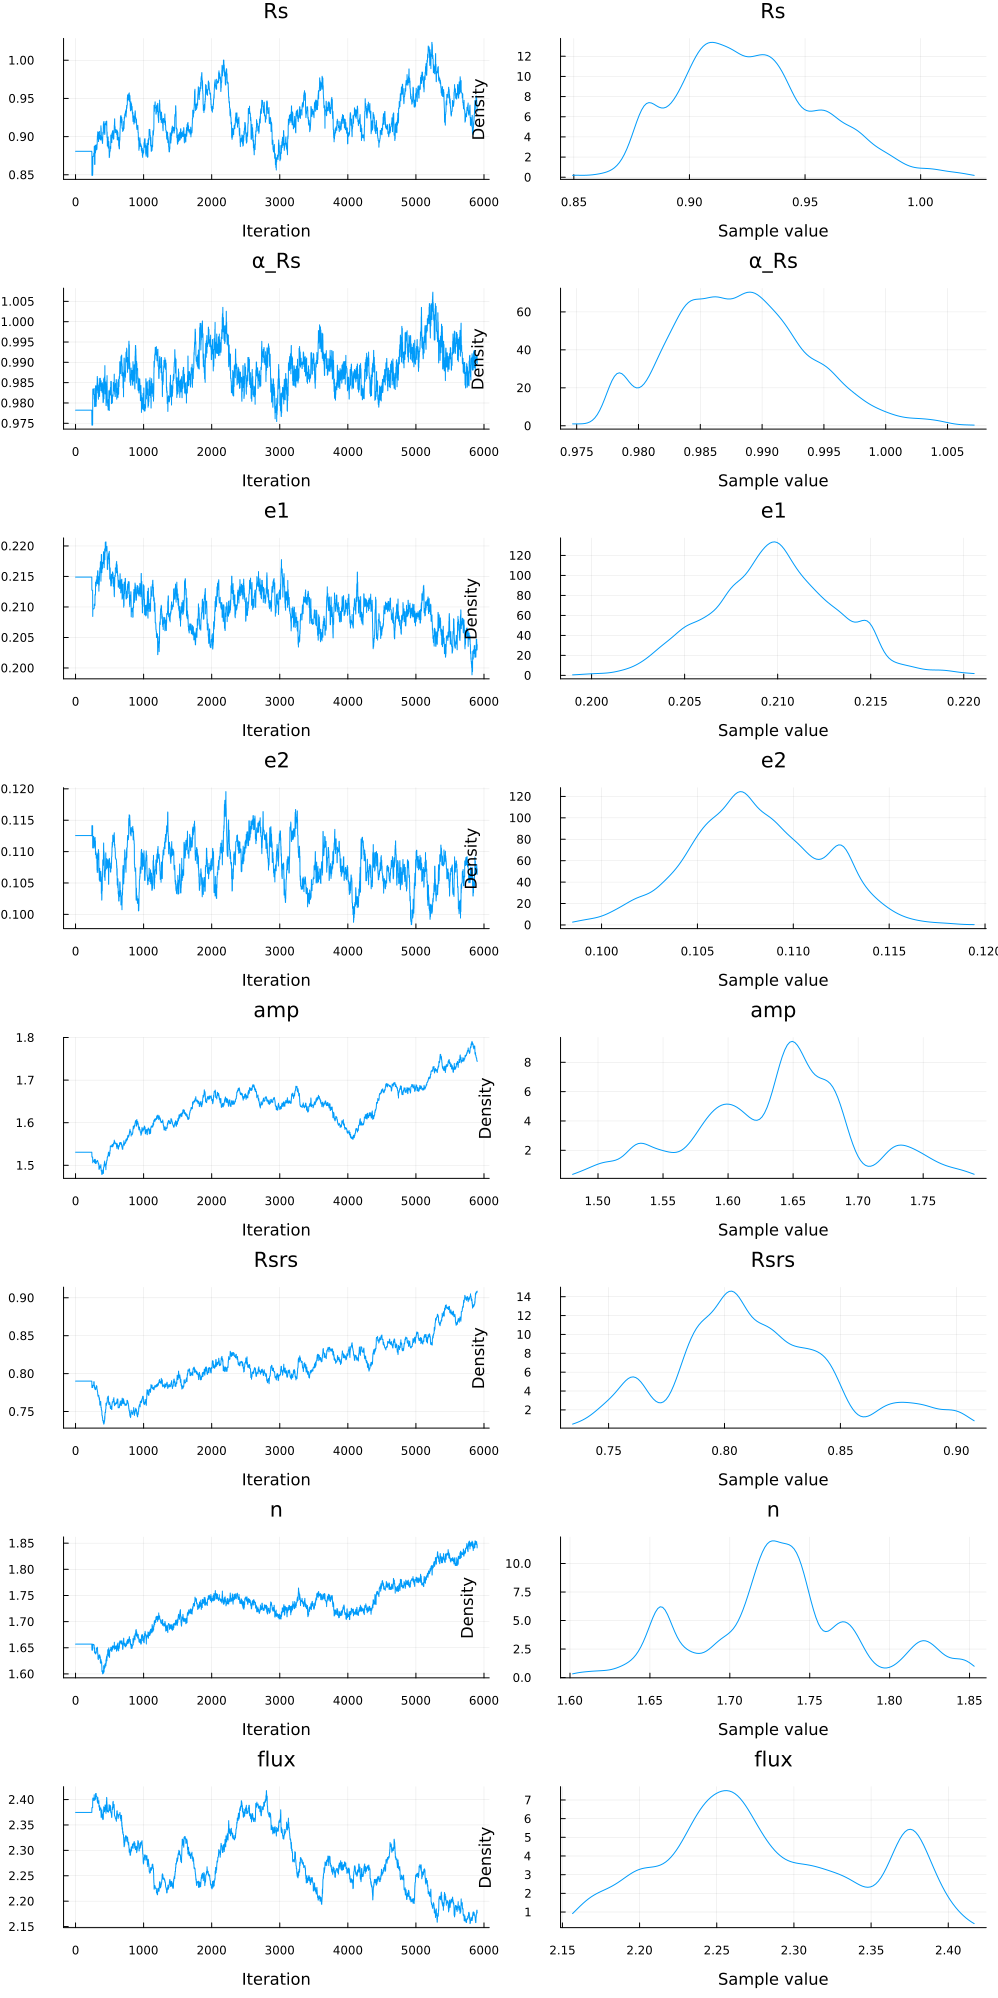

In [46]:
chn = Chains(summary', [:Rs, :α_Rs, :e1, :e2, :amp, :Rsrs, :n, :flux])
ChainPlot = StatsPlots.plot(chn) 

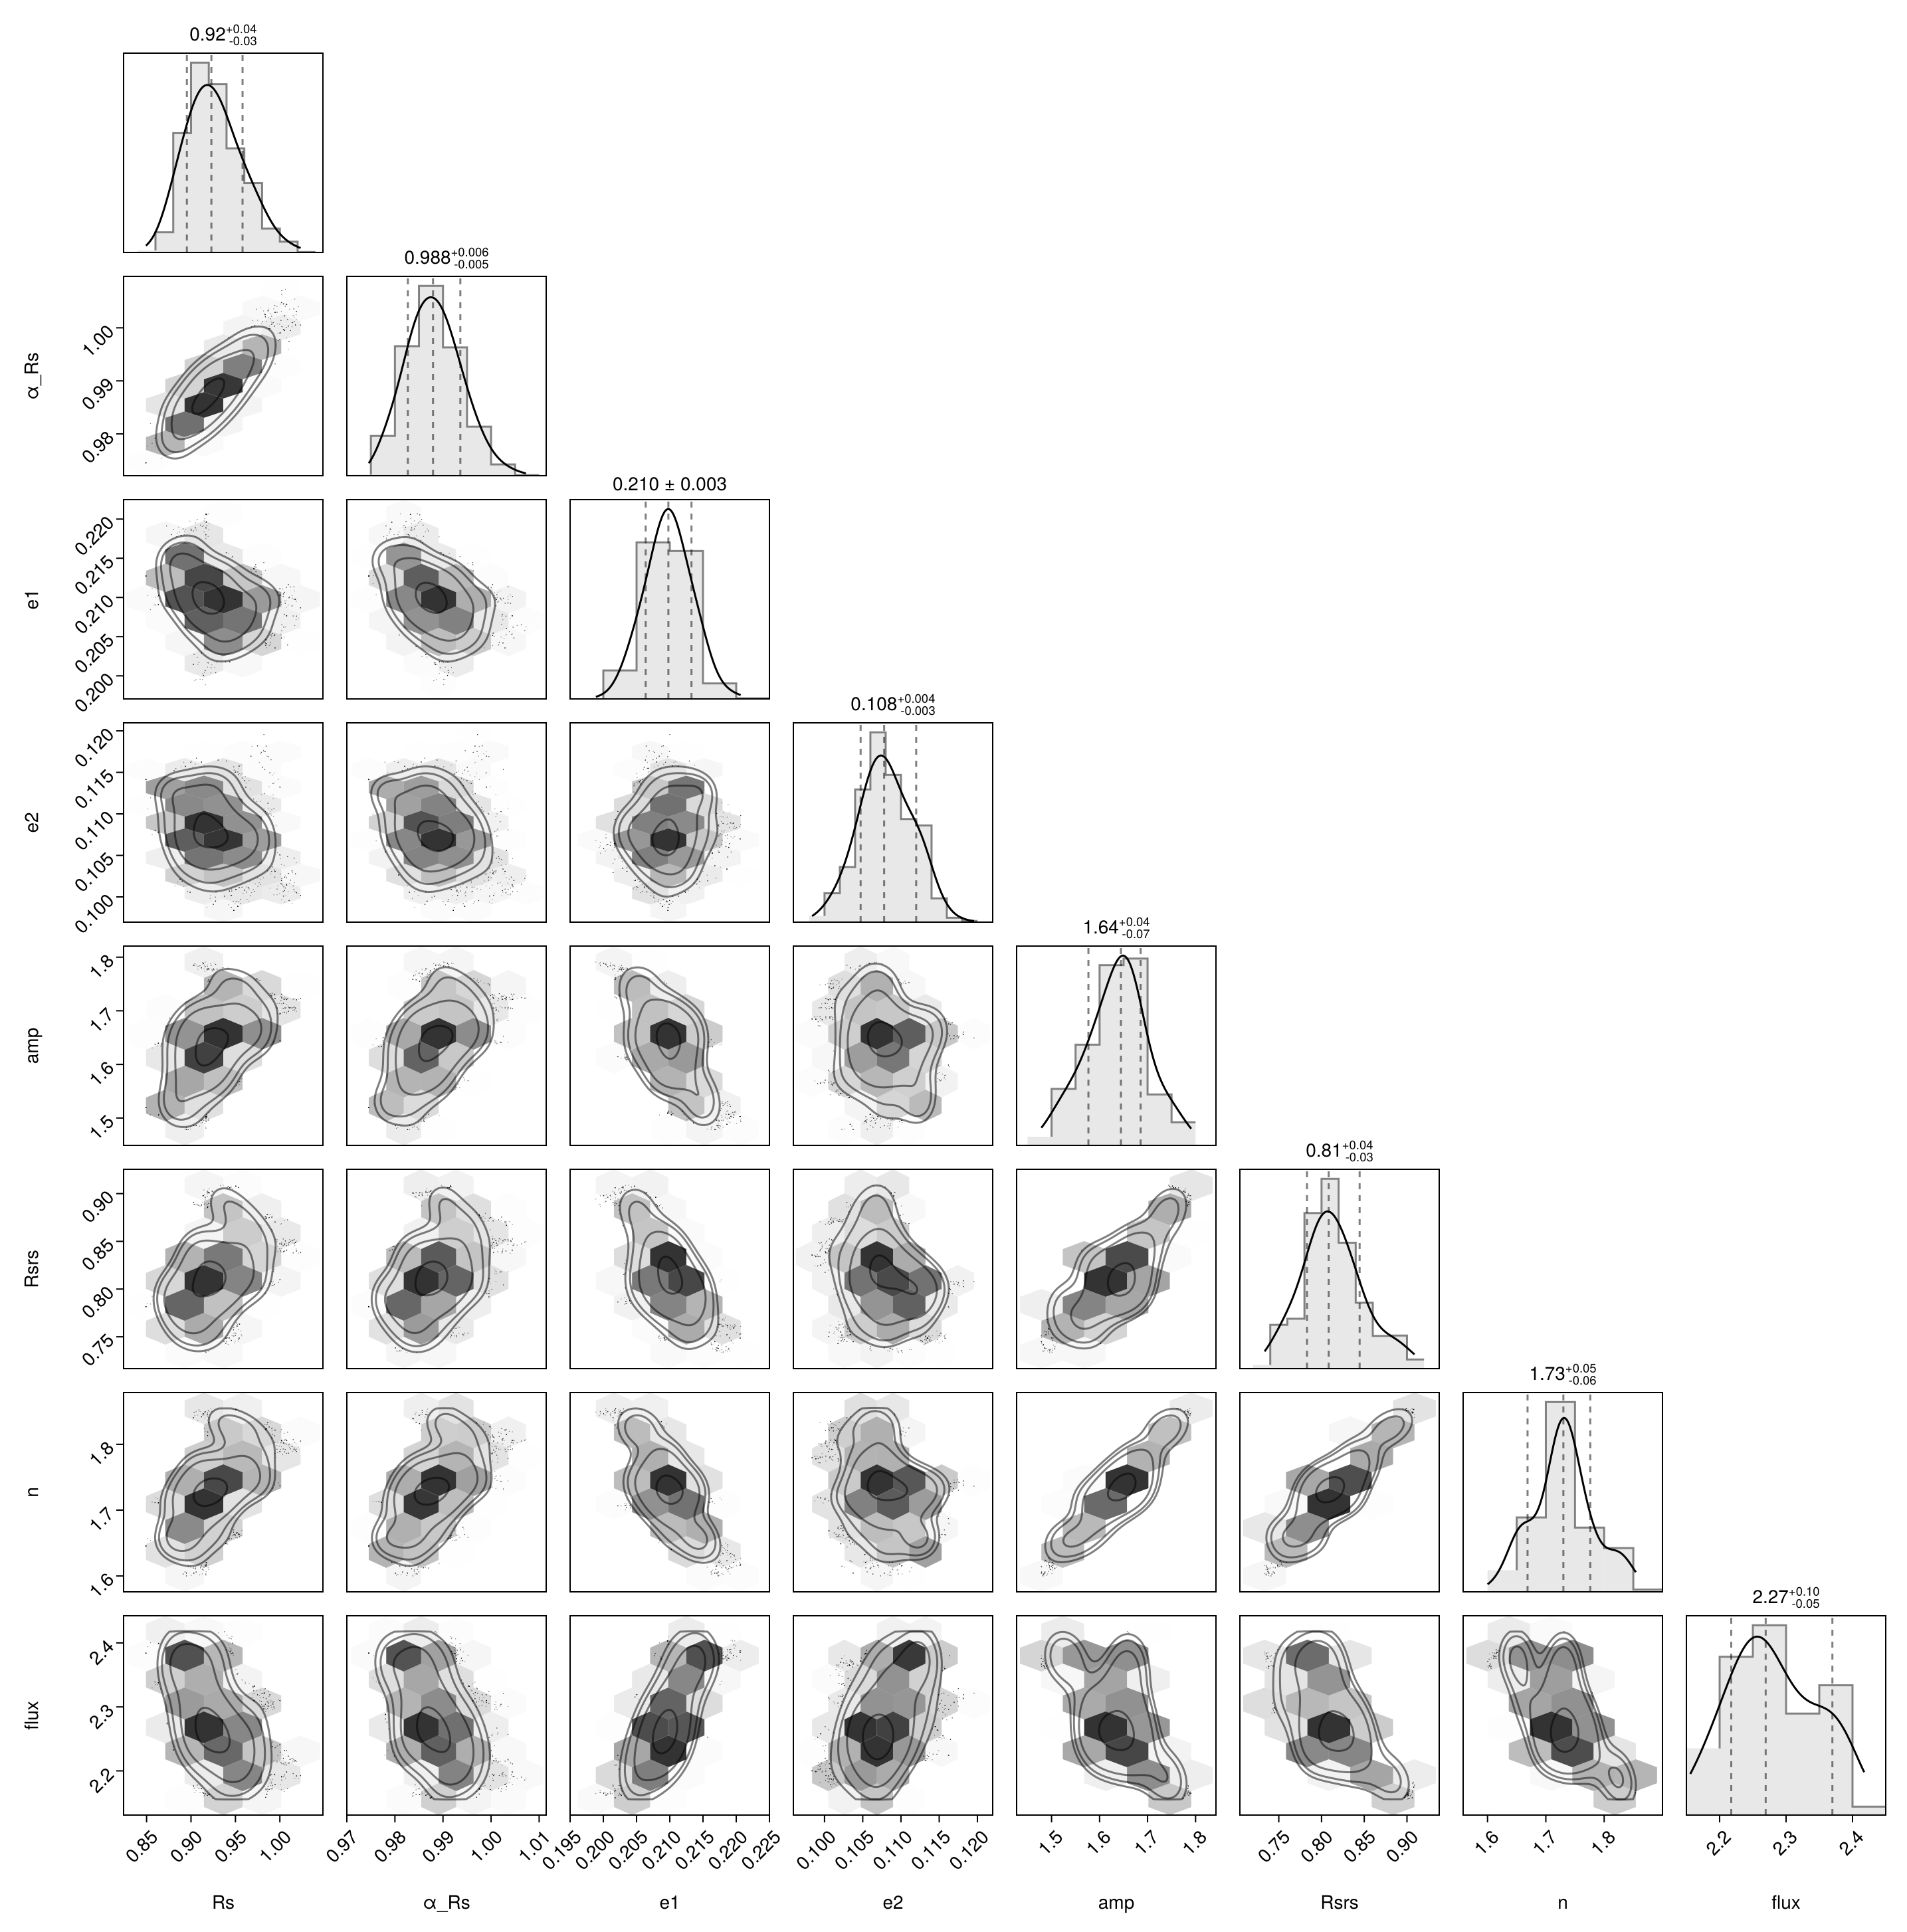

In [47]:
corner_fig = PairPlots.pairplot(chn)


|  MCMC （500 strps MH，3-para SIS）                     |   
|  grid   |   CPU    |    GPU   |   acc  |    ms/step(CPU) | ms/step(GPU)|
|------|------|------|------|------|------|
|   64²  |    0.5 s   |   1.7 s  |  0.3  |    1.0    |     3.4|
|  128²   |   0.8 s  |    0.3 s  |  2.7    |     1.7   |      0.6|
|  256²   |   6.9 s   |   0.4 s  | 19.1   |  13.9    |     0.7|